# 1. Introduction

### What is leave-one-out? Provide limitations and strengths.

LOOCV is a type of cross-validation method that involves leaving out one sample from the training set and using the remaining samples to train the model. частный случай метода k-Fold: в нём каждый фолд состоит ровно из одного семпла

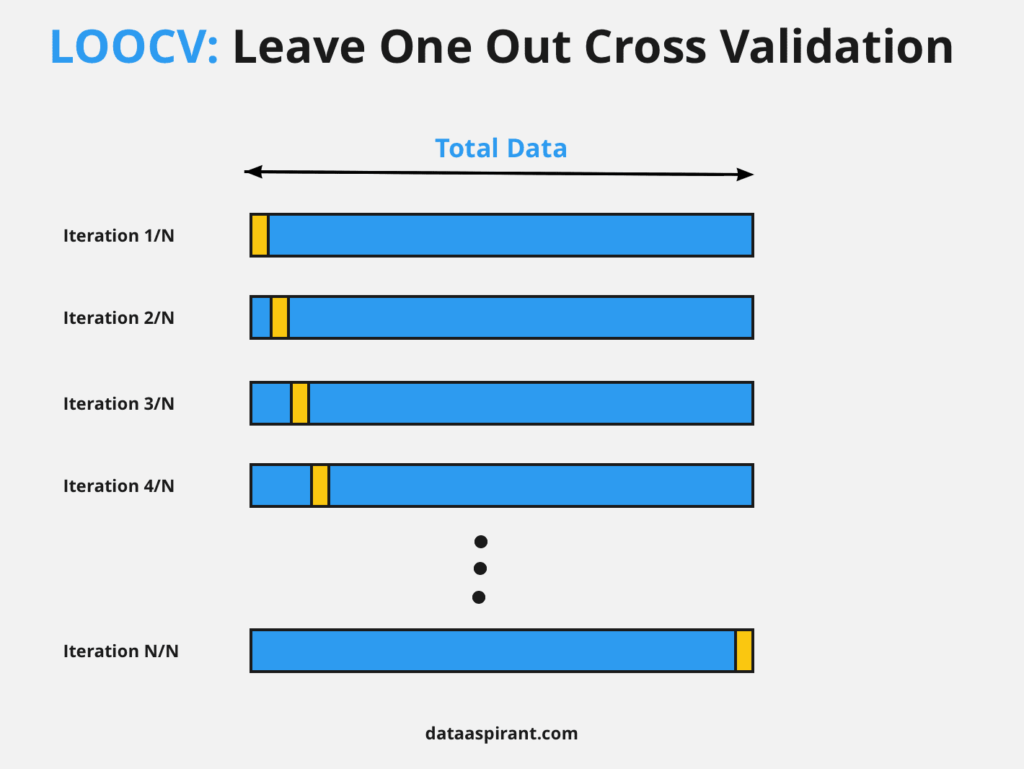

This process is repeated for each sample in the dataset, and the performance of the model is evaluated based on how well it predicts the left-out sample.

Benefits: it uses all the data from dataset. <br> Drawback: it takes a lot of time to compute the results, high variance

### Grid Search, Randomized Grid Search, and Bayesian optimization

#### Grid Search
перебор по сетке (Grid Search):<br>
для каждого гиперпараметра фиксируется несколько значений;<br>
перебираются все комбинации значений различных гиперпараметров, на каждой из этих комбинаций модель обучается и тестируется;<br>
выбирается комбинация, на которой модель показывает лучшее качество.

#### Random Search

random search selects hyperparameters randomly from specified distributions. This enables sampling from a wider range of values.<br>

The number of combinations to try can be specified instead of having to evaluate all grid points like in grid search. This greatly reduces computational expense.

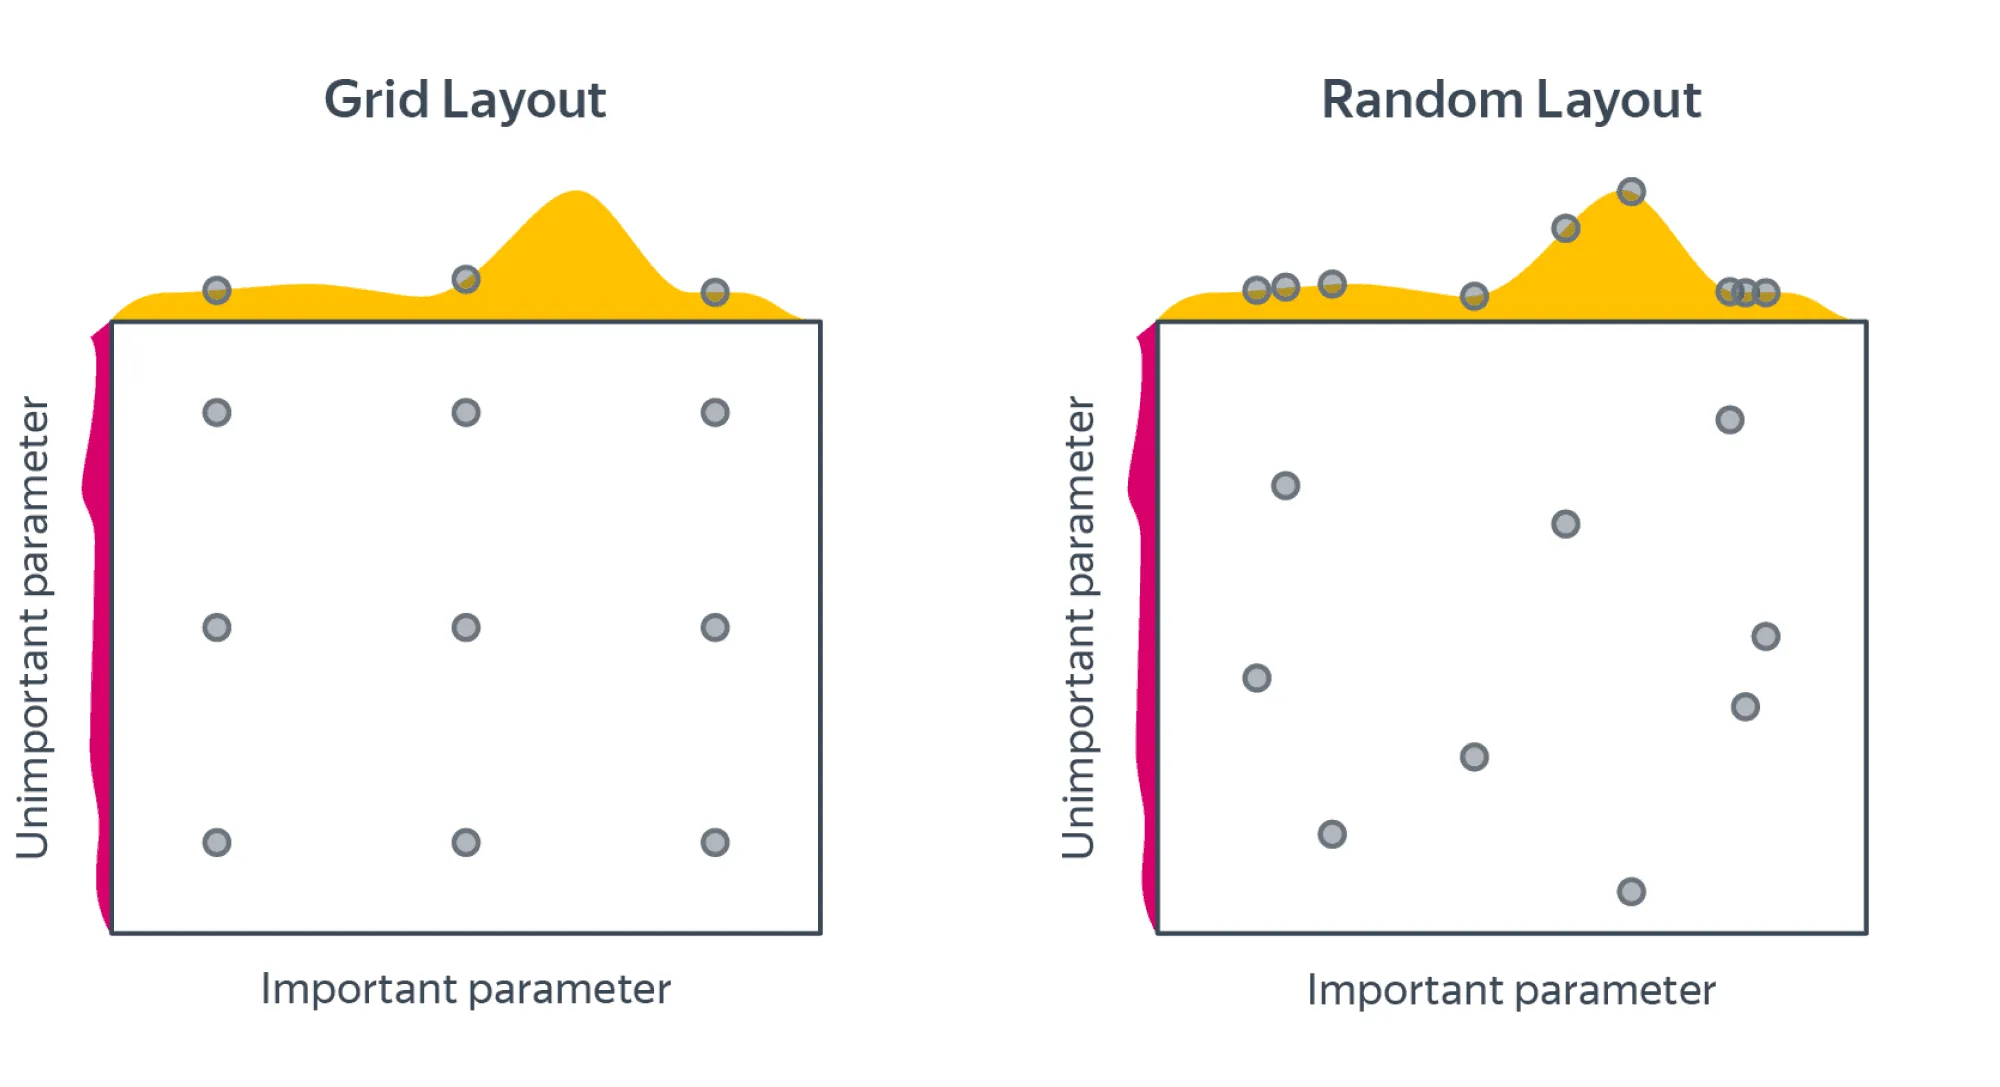

Random Search может за то же число итераций, что и Grid Search, рассмотреть более разнообразные значения гиперпараметров. Тем самым он с большей вероятностью найдёт те значения, которые больше всего влияют на качество модели, а значит, с большей вероятностью найдёт наилучшую комбинацию значений гиперпараметров.

## Bayesian optimization

2 компонента: <br>
1. вероятностная модель, которая приближает распределение значений целевой функции в зависимости от имеющихся исторических данных
2. функция, которая позволяет по некоторым статистикам текущей вероятностной модели функции f указать, в какой следующей точке нужно вычислить значение f. Эта функция называется acquisition function.

Сильные стороны:<br>
*использует результаты предыдущих итераций;<br>
*может моделировать внутренние зависимости между гиперпараметрами <br>
*может расширять заданные изначально границы множества поиска гиперпараметров;<br>
*достигает более высокого качества, чем Random Search, если удалось провести достаточное количество итераций.

### Feature selection

#### Filter methods: Ch-square test

\chi^{2}=\sum \frac{(observed - expected)^{2}}{expected} <br>
для измерения зависимости между признаками и целевой переменной

#### Pearson Correlation <br>
используется для выявления линейной зависимости между признаками и целевой переменной

#### Wrapper methods

классификатор запускается на разных подмножествах фич исходного тренировочного сета. После чего выбирается подмножество фич с наилучшими параметрами на обучающей выборке. А затем он тестируется на тестовом сете (тестовый сет не участвует в процессе выбора оптимального подмножества).

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import lightgbm
import scipy
import statsmodels.api as sm
from collections import Counter
from sklearn.metrics import mean_absolute_error as MAE 
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import r2_score as R2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, LassoCV, ElasticNet
from sklearn.model_selection import train_test_split, KFold, GroupKFold, StratifiedKFold, TimeSeriesSplit
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
import logging
import shap
import optuna

# preprocessing

In [3]:
train=pd.read_json('../datasets/train.json')

In [4]:
train=train[(train['price']>np.percentile(train['price'], 1)) & (train['price']<np.percentile(train['price'],99))]

In [5]:
train['interest_level']=train['interest_level'].replace({'low': 0, 'medium': 1, 'high' :2})
train.head()

/tmp/ipykernel_24824/431221843.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train['interest_level']=train['interest_level'].replace({'low': 0, 'medium': 1, 'high' :2})


,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,1
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,0
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,1
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,1
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,0


In [6]:
features=train['features']
all_features=[]
for line in features:
    all_features.extend(line)

In [7]:
top_features=Counter(all_features)
top_features.most_common(20)

[('Elevator', 25375),
 ('Hardwood Floors', 23146),
 ('Cats Allowed', 23135),
 ('Dogs Allowed', 21652),
 ('Doorman', 20479),
 ('Dishwasher', 20081),
 ('No Fee', 17793),
 ('Laundry in Building', 16082),
 ('Fitness Center', 12989),
 ('Pre-War', 8971),
 ('Laundry in Unit', 8437),
 ('Roof Deck', 6417),
 ('Outdoor Space', 5132),
 ('Dining Room', 4890),
 ('High Speed Internet', 4223),
 ('Balcony', 2898),
 ('Swimming Pool', 2643),
 ('Laundry In Building', 2564),
 ('New Construction', 2504),
 ('Terrace', 2177)]

In [8]:
common_features=[f for f,count in top_features.most_common(20)]
train_df=train[['bathrooms', 'bedrooms', 'interest_level', 'features', 'price', 'created']].copy()
for f in common_features:
    train_df[f]=train_df['features'].apply(lambda x: 1 if f in x else 0)
train_df.drop(columns='features', inplace=True)

train_df.head()

,bathrooms,bedrooms,interest_level,price,created,Elevator,Hardwood Floors,Cats Allowed,Dogs Allowed,Doorman,...,Laundry in Unit,Roof Deck,Outdoor Space,Dining Room,High Speed Internet,Balcony,Swimming Pool,Laundry In Building,New Construction,Terrace
4,1.0,1,1,2400,2016-06-16 05:55:27,0,1,1,1,0,...,0,0,0,1,0,0,0,0,0,0
6,1.0,2,0,3800,2016-06-01 05:44:33,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
9,1.0,2,1,3495,2016-06-14 15:19:59,1,1,0,0,1,...,1,0,0,0,0,0,0,0,0,0
10,1.5,3,1,3000,2016-06-24 07:54:24,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15,1.0,0,0,2795,2016-06-28 03:50:23,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


# 3 - splitting data

In [9]:
X=train_df.drop(columns='price')
y=train_df['price']

In [10]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48343 entries, 4 to 124009
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   bathrooms            48343 non-null  float64
 1   bedrooms             48343 non-null  int64  
 2   interest_level       48343 non-null  int64  
 3   created              48343 non-null  object 
 4   Elevator             48343 non-null  int64  
 5   Hardwood Floors      48343 non-null  int64  
 6   Cats Allowed         48343 non-null  int64  
 7   Dogs Allowed         48343 non-null  int64  
 8   Doorman              48343 non-null  int64  
 9   Dishwasher           48343 non-null  int64  
 10  No Fee               48343 non-null  int64  
 11  Laundry in Building  48343 non-null  int64  
 12  Fitness Center       48343 non-null  int64  
 13  Pre-War              48343 non-null  int64  
 14  Laundry in Unit      48343 non-null  int64  
 15  Roof Deck            48343 non-null  int

In [11]:
#X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.3)
def split_train_test_two(X, y, test_size=0.2): #без random state
    #X_array=np.ndarray(X)
    #y_array=np.ndarray(y)
    n_samples=len(X)
    n_test=int(n_samples*test_size)
    n_train=n_samples-n_test
    ind=np.arange(n_samples)
    np.random.shuffle(ind) #по дефолту всегда стоит перемешивание
    test_ind=ind[:n_test]
    train_ind=ind[n_test:]

    X_train=X.iloc[train_ind]
    X_test=X.iloc[test_ind]
    y_train=y.iloc[train_ind]
    y_test=y.iloc[test_ind]
    return X_train, X_test, y_train, y_test

In [12]:
X_train, X_test, y_train, y_test = split_train_test_two(X, y, test_size=0.2)

In [13]:
display(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(38675, 24)

(9668, 24)

(38675,)

(9668,)

In [14]:
def split_train_test_valid(X, y, test_size=0.2, validation_size=0.2):
    n_samples=len(X)
    n_test=int(n_samples*test_size)
    n_valid=int(n_samples*validation_size)
    ind=np.arange(n_samples)
    np.random.shuffle(ind)
    ind_test=ind[:n_test]
    ind_valid_train=ind[n_test:]
    ind_valid=ind_valid_train[:n_valid]
    ind_train=ind_valid_train[n_valid:]
    X_train=X.iloc[ind_train]
    X_test=X.iloc[ind_test]
    y_train=y.iloc[ind_train]
    y_test=y.iloc[ind_test]
    X_valid=X.iloc[ind_valid]
    y_valid=y.iloc[ind_valid]

    return X_train,X_test,X_valid,y_train,y_test,y_valid
    
    

In [15]:
X_train, X_test, X_valid, y_train, y_test, y_valid = split_train_test_valid(X, y, test_size=0.2, validation_size=0.2)

In [16]:
display(X_train.shape, X_test.shape, X_valid.shape, y_train.shape, y_test.shape, y_valid.shape)

(29007, 24)

(9668, 24)

(9668, 24)

(29007,)

(9668,)

(9668,)

In [17]:
X['created']=pd.to_datetime(X['created'])

In [18]:
X.head()

,bathrooms,bedrooms,interest_level,created,Elevator,Hardwood Floors,Cats Allowed,Dogs Allowed,Doorman,Dishwasher,...,Laundry in Unit,Roof Deck,Outdoor Space,Dining Room,High Speed Internet,Balcony,Swimming Pool,Laundry In Building,New Construction,Terrace
4,1.0,1,1,2016-06-16 05:55:27,0,1,1,1,0,1,...,0,0,0,1,0,0,0,0,0,0
6,1.0,2,0,2016-06-01 05:44:33,1,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
9,1.0,2,1,2016-06-14 15:19:59,1,1,0,0,1,1,...,1,0,0,0,0,0,0,0,0,0
10,1.5,3,1,2016-06-24 07:54:24,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15,1.0,0,0,2016-06-28 03:50:23,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
def split_by_date(X, y, date):
    X=X.sort_values(by='created')
    train_df=X[X['created']<date]
    test_df=X[X['created']>=date]
    X_train=X.loc[train_df.index]
    X_test=X.loc[test_df.index]
    y_train=y.loc[train_df.index]
    y_test=y.loc[test_df.index]

    return X_train, X_test, y_train, y_test

In [20]:
X_train, X_test, y_train, y_test = split_by_date(X,y, '2016-06-01')

In [21]:
display(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(31551, 24)

(16792, 24)

(31551,)

(16792,)

In [22]:
def split_by_date_three(X, y, date_valid, date_test):
    X=X.sort_values(by='created')
    train_df=X[X['created']<date_valid]
    valid_df=X[(X['created']>=date_valid) & (X['created']<date_test)]
    test_df=X[X['created']>=date_test]
    X_train=X.loc[train_df.index]
    X_valid=X.loc[valid_df.index]
    X_test=X.loc[test_df.index]
    y_train=y.loc[train_df.index]
    y_valid=y.loc[valid_df.index]
    y_test=y.loc[test_df.index]

    return X_train, X_valid, X_test, y_train, y_valid, y_test

In [23]:
X_train, X_valid, X_test, y_train, y_valid, y_test=split_by_date_three(X,y, '2016-05-01', '2016-06-01')

In [24]:
display(X_train.shape, X_test.shape, X_valid.shape, y_train.shape, y_test.shape, y_valid.shape)

(16091, 24)

(16792, 24)

(15460, 24)

(16091,)

(16792,)

(15460,)

# implementing cross-validation methods

In [25]:
def k_folds_my(X,k):
    n_samples=len(X)
    ind=np.arange(n_samples)
    step=int(n_samples//k)
    current=0
    folds=[]
    for i in range(k):
        test_start=current
        test_end=current+step
        ind_test=ind[test_start:test_end]
        ind_train=np.concatenate([ind[:test_start], ind[test_end:]])
        #Join a sequence of arrays along an existing axis.
        current=test_end
    
        folds.append((ind_train,ind_test))
    return folds
        

In [26]:
def k_grouped_folds_my(X, group, k): #чтобы в train test не было из однаковых классов
    n_samples=len(X)
    ind=np.arange(n_samples)
    unique_groups=np.unique(group)
    step=int(n_samples//k)
    n_groups=len(unique_groups)
    fold_unique=int(n_groups//k)
    folds=[]
    for i in range(k):
        test_groups = unique_groups[i * fold_unique : (i + 1) * fold_unique]
        test_mask=np.isin(group, test_groups) #boolean
        ind_test=ind[test_mask]
        ind_train=ind[~test_mask] #маска-побитовое отрицание-все что НЕ 
        folds.append((ind_train, ind_test))

    return folds


In [27]:
def stratified_kfolds_my(X, stratify, k): #чтобы было одинаковое соотношение класса в каждом сете
    n_samples=len(X)
    ind=np.arange(n_samples)
    unique_classes=np.unique(stratify)
    folds=[]
    for i in range(k):
        test_ind=[]
        train_ind=[]
        for clas in unique_classes:
            class_ind = np.where(stratify == clas)[0]
            fold= len(class_ind)//k
            start=i * fold 
            if i == k - 1:
                end = len(class_ind)
            else:
                end = (i + 1) * fold
            test_class_ind=class_ind[start:end]
            train_class_ind = np.setdiff1d(class_ind, test_class_ind) #те из class_ind которые отсутствуют в test_ind
            test_ind.extend(test_class_ind)
            train_ind.extend(train_class_ind)
        folds.append((np.sort(train_ind), np.sort(test_ind)))
    return folds

In [28]:
def timedate_kfolds_my(X, date, k):
    
    
    X_sorted=X.sort_values(by=date)
    n_samples=len(X_sorted)
    ind=np.arange(n_samples)
    fold= int(n_samples//k)
    folds=[]
    for i in range(k):
        start = i * fold
        stop = (i + 1) * fold
        test_ind = ind[start:stop]
        train_ind = ind[:stop]
        folds.append((train_ind,test_ind))
    return folds
         


# Comparison

In [29]:
X=train_df.drop(columns='price')
y=train_df['price']

In [30]:
display(X.shape,y.shape)

(48343, 24)

(48343,)

In [31]:
X_train, X_test, y_train, y_test = split_train_test_two(X, y, test_size=0.2)
display(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(38675, 24)

(9668, 24)

(38675,)

(9668,)

In [32]:
#sklearn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
display(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(38674, 24)

(9669, 24)

(38674,)

(9669,)

In [33]:
X_train, X_test,X_valid, y_train, y_test, y_valid=split_train_test_valid(X, y, test_size=0.2, validation_size=0.2)
display(X_train.shape, X_test.shape, X_valid.shape, y_train.shape, y_test.shape, y_valid.shape)

(29007, 24)

(9668, 24)

(9668, 24)

(29007,)

(9668,)

(9668,)

in sklearn we dont have such methods as splitting by date and splitting into 3 parts with validation set

In [34]:
for i, (train_ind, test_ind) in enumerate(k_folds_my(X,4)):
    print(f"index: {i}")
    print(f"traind_ind: {train_ind}")
    print(f"test_ind:{test_ind}")

index: 0
traind_ind: [12085 12086 12087 ... 48340 48341 48342]
test_ind:[    0     1     2 ... 12082 12083 12084]
index: 1
traind_ind: [    0     1     2 ... 48340 48341 48342]
test_ind:[12085 12086 12087 ... 24167 24168 24169]
index: 2
traind_ind: [    0     1     2 ... 48340 48341 48342]
test_ind:[24170 24171 24172 ... 36252 36253 36254]
index: 3
traind_ind: [    0     1     2 ... 48340 48341 48342]
test_ind:[36255 36256 36257 ... 48337 48338 48339]


In [35]:
for i, (train_ind, test_ind) in enumerate(KFold(n_splits=4).split(X)):
    print(f"index: {i}")
    print(f"traind_ind: {train_ind}")
    print(f"test_ind:{test_ind}")

index: 0
traind_ind: [12086 12087 12088 ... 48340 48341 48342]
test_ind:[    0     1     2 ... 12083 12084 12085]
index: 1
traind_ind: [    0     1     2 ... 48340 48341 48342]
test_ind:[12086 12087 12088 ... 24169 24170 24171]
index: 2
traind_ind: [    0     1     2 ... 48340 48341 48342]
test_ind:[24172 24173 24174 ... 36255 36256 36257]
index: 3
traind_ind: [    0     1     2 ... 36255 36256 36257]
test_ind:[36258 36259 36260 ... 48340 48341 48342]


In [36]:
for i, (train_ind, test_ind) in enumerate(k_grouped_folds_my(X, X['interest_level'], k=3)):
    print(f"index: {i}")
    print(f"traind_ind: {train_ind}")
    print(f"test_ind:{test_ind}")


index: 0
traind_ind: [    0     2     3 ... 48340 48341 48342]
test_ind:[    1     4     5 ... 48336 48337 48338]
index: 1
traind_ind: [    1     4     5 ... 48337 48338 48342]
test_ind:[    0     2     3 ... 48339 48340 48341]
index: 2
traind_ind: [    0     1     2 ... 48339 48340 48341]
test_ind:[    7    17    31 ... 48303 48332 48342]


In [37]:
for i, (train_ind, test_ind) in enumerate(GroupKFold(n_splits=3).split(X, groups=X['interest_level'])):
    print(f"index: {i}")
    print(f"traind_ind: {train_ind}")
    print(f"test_ind:{test_ind}")


index: 0
traind_ind: [    0     2     3 ... 48340 48341 48342]
test_ind:[    1     4     5 ... 48336 48337 48338]
index: 1
traind_ind: [    1     4     5 ... 48337 48338 48342]
test_ind:[    0     2     3 ... 48339 48340 48341]
index: 2
traind_ind: [    0     1     2 ... 48339 48340 48341]
test_ind:[    7    17    31 ... 48303 48332 48342]


In [38]:
for i, (train_ind, test_ind) in enumerate(stratified_kfolds_my(X, stratify=X['interest_level'], k=3)):
    print(f"index: {i}")
    print(f"traind_ind: {train_ind}")
    print(f"test_ind:{test_ind}")


index: 0
traind_ind: [15996 15997 15998 ... 48340 48341 48342]
test_ind:[    0     1     2 ... 16453 16456 16461]
index: 1
traind_ind: [    0     1     2 ... 48340 48341 48342]
test_ind:[15996 15997 15998 ... 32352 32358 32361]
index: 2
traind_ind: [    0     1     2 ... 32352 32358 32361]
test_ind:[32169 32171 32172 ... 48340 48341 48342]


In [39]:
for i, (train_ind, test_ind) in enumerate(StratifiedKFold(n_splits=3).split(X, X['interest_level'])):
    print(f"index: {i}")
    print(f"traind_ind: {train_ind}")
    print(f"test_ind:{test_ind}")

index: 0
traind_ind: [15996 15997 15998 ... 48340 48341 48342]
test_ind:[    0     1     2 ... 16456 16461 16465]
index: 1
traind_ind: [    0     1     2 ... 48340 48341 48342]
test_ind:[15996 15997 15998 ... 32361 32367 32371]
index: 2
traind_ind: [    0     1     2 ... 32361 32367 32371]
test_ind:[32169 32171 32172 ... 48340 48341 48342]


In [40]:

for i, (train_ind, test_ind) in enumerate(timedate_kfolds_my(X, date='created', k=3)):
    print(f"index: {i}")
    print(f"traind_ind: {train_ind}")
    print(f"test_ind:{test_ind}")

index: 0
traind_ind: [    0     1     2 ... 16111 16112 16113]
test_ind:[    0     1     2 ... 16111 16112 16113]
index: 1
traind_ind: [    0     1     2 ... 32225 32226 32227]
test_ind:[16114 16115 16116 ... 32225 32226 32227]
index: 2
traind_ind: [    0     1     2 ... 48339 48340 48341]
test_ind:[32228 32229 32230 ... 48339 48340 48341]


In [41]:

for i, (train_ind, test_ind) in enumerate(TimeSeriesSplit( n_splits=3).split(X, y=X['created'])):
    print(f"index: {i}")
    print(f"traind_ind: {train_ind}")
    print(f"test_ind:{test_ind}")

index: 0
traind_ind: [    0     1     2 ... 12085 12086 12087]
test_ind:[12088 12089 12090 ... 24170 24171 24172]
index: 1
traind_ind: [    0     1     2 ... 24170 24171 24172]
test_ind:[24173 24174 24175 ... 36255 36256 36257]
index: 2
traind_ind: [    0     1     2 ... 36255 36256 36257]
test_ind:[36258 36259 36260 ... 48340 48341 48342]


# Feature Selection

In [42]:
X=X.drop(columns=['created'])
y=train_df['price']

In [43]:
X_train, X_test, X_valid, y_train, y_test, y_valid = split_train_test_valid(X, y, test_size=0.2, validation_size=0.2)

In [44]:
scaler=MinMaxScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)
X_valid_scaled=scaler.fit_transform(X_valid)

Lasso-CV: Lasso linear model with iterative fitting along a regularization path.

In [45]:
lasso=LassoCV(cv=10)
lasso.fit(X_train_scaled, y_train)
lasso.alpha_

np.float64(0.22232049847789945)

In [46]:
lasso.coef_

array([6738.6144286 , 3797.24044397, -835.94690522,  220.58894257,
       -126.02030122,  -54.01178759,  105.20085943,  562.5822245 ,
        145.63272414,  -89.23544345, -189.82675183,  199.87567896,
        -50.87280703,  437.45747503,  -83.47069148,  -92.81281892,
        138.15199261, -191.25306571,   -0.        ,   26.9291063 ,
       -198.71198856, -149.99916373,  155.66522343])

In [47]:
metrics = pd.DataFrame(columns=['name', 'metric', 'train', 'valid', 'test'])

In [48]:
def add_metrics(model_name, name, X_train_scaled, X_test_scaled, X_valid_scaled):
    y_train_predict=model_name.predict(X_train_scaled)
    y_test_predict=model_name.predict(X_test_scaled)
    y_valid_predict=model_name.predict(X_valid_scaled)

    metrics.loc[len(metrics)] = [name,'mae', MAE(y_train, y_train_predict), MAE(y_valid, y_valid_predict), MAE(y_test,y_test_predict)]
    metrics.loc[len(metrics)] = [name,'rmse', np.sqrt(MSE(y_train, y_train_predict)), np.sqrt(MSE(y_valid, y_valid_predict)), np.sqrt(MSE(y_test,y_test_predict))]
    metrics.loc[len(metrics)] = [name,'r2', R2(y_train, y_train_predict), R2(y_valid, y_valid_predict), R2(y_test,y_test_predict)]

In [49]:
add_metrics(lasso, "lassoCV",X_train_scaled, X_valid_scaled,X_test_scaled)

In [50]:
metrics

,name,metric,train,valid,test
0,lassoCV,mae,687.115093,1507.535832,1453.306410
1,lassoCV,rmse,989.890179,2081.170088,2025.777375
2,lassoCV,r2,0.607425,-0.650259,-0.669753


In [51]:
feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'coefficient': lasso.coef_,
        'abs_coef': np.abs(lasso.coef_)
    }).sort_values('abs_coef', ascending=False)

In [52]:
top_features = feature_importance.head(10)['feature'].tolist()

In [53]:
X_train_top=X_train[top_features]
X_valid_top=X_valid[top_features]
X_test_top=X_test[top_features]

In [54]:

X_train_top_norm=scaler.fit_transform(X_train_top)
X_valid_top_norm=scaler.fit_transform(X_valid_top)
X_test_top_norm=scaler.fit_transform(X_test_top)

In [55]:
lasso_top_10=LassoCV(cv=10)
lasso_top_10.fit(X_train_top_norm, y_train)

LassoCV(cv=10)

In [56]:
add_metrics(lasso_top_10, "lasso_top10_weights", X_train_top_norm, X_valid_top_norm,X_test_top_norm)

In [57]:
corr_matrix=train_df.drop(columns='created').corr()
corr_matrix = corr_matrix.sort_values(by='price', ascending=False)
top_10_corr = corr_matrix.index[1:11].tolist()
print(top_10_corr)

['bathrooms', 'bedrooms', 'Doorman', 'Laundry in Unit', 'Fitness Center', 'Dishwasher', 'Dining Room', 'Elevator', 'Outdoor Space', 'Laundry in Building']


In [58]:
X_train_corr=X_train[top_10_corr]
X_valid_corr=X_valid[top_10_corr]
X_test_corr=X_test[top_10_corr]

In [59]:

X_train_corr_norm=scaler.fit_transform(X_train_corr)
X_valid_corr_norm=scaler.fit_transform(X_valid_corr)
X_test_corr_norm=scaler.fit_transform(X_test_corr)

In [60]:
lasso_corr=LassoCV(cv=10)
lasso_corr.fit(X_train_corr_norm, y_train)

LassoCV(cv=10)

In [61]:
add_metrics(lasso_corr, "lasso_top10_corr", X_train_corr_norm, X_valid_corr_norm, X_test_corr_norm)

In [62]:
lasso_permut=LassoCV(cv=10)
lasso_permut.fit(X_train_scaled, y_train)
res=permutation_importance(lasso_permut, X_train_scaled, y_train, n_repeats=10)
importance_mean = res.importances_mean
importance = np.argsort(importance_mean)[::-1].tolist()
top_importance=importance[:10]
top_importance

[0, 1, 7, 2, 13, 3, 10, 11, 8, 4]

In [63]:
X_train_10_importance = X_train.iloc[:, top_importance]
X_valid_10_importance = X_valid.iloc[:, top_importance]
X_test_10_importance = X_test.iloc[:, top_importance]

In [64]:
X_train_10_importance_norm=scaler.fit_transform(X_train_10_importance)
X_valid_10_importance_norm=scaler.fit_transform(X_valid_10_importance)
X_test_10_importance_norm=scaler.fit_transform(X_test_10_importance)

In [65]:
lasso_permut_final=LassoCV(cv=10)
lasso_permut_final.fit(X_train_10_importance_norm, y_train)

LassoCV(cv=10)

In [66]:
add_metrics(lasso_corr, "lasso_top10_permutation", X_train_10_importance_norm, X_valid_10_importance_norm, X_test_10_importance_norm)

In [67]:
lasso_cv=LassoCV(cv=10)
lasso_cv.fit(X_train, y_train)
explainer = shap.Explainer(lasso_cv, X_train)
shap_values = explainer(X_train)

In [68]:
importance_values = np.abs(shap_values.values).mean(axis=0)
top_10_shap = np.argsort(importance_values)[::-1][:10].tolist()

In [69]:
X_train_10_shap = X_train.iloc[:, top_10_shap]
X_valid_10_shap = X_valid.iloc[:, top_10_shap]
X_test_10_shap = X_test.iloc[:, top_10_shap]

In [70]:
X_train_10_shap_norm=scaler.fit_transform(X_train_10_shap)
X_valid_10_shap_norm=scaler.fit_transform(X_valid_10_shap)
X_test_10_shap_norm=scaler.fit_transform(X_test_10_shap)

In [71]:
lasso_shap=LassoCV(cv=10)
lasso_shap.fit(X_train_10_shap_norm, y_train)
add_metrics(lasso_corr, "lasso_shap", X_train_10_shap_norm, X_valid_10_shap_norm, X_test_10_shap_norm)

In [72]:
metrics

,name,metric,train,valid,test
0,lassoCV,mae,687.115093,1507.535832,1453.306410
1,lassoCV,rmse,989.890179,2081.170088,2025.777375
2,lassoCV,r2,0.607425,-0.650259,-0.669753
3,lasso_top10_weights,mae,690.669278,1506.120112,1452.914895
4,lasso_top10_weights,rmse,995.241244,2081.616669,2026.226859
5,lasso_top10_weights,r2,0.603169,-0.650967,-0.670494
6,lasso_top10_corr,mae,719.099805,1484.572631,1441.082600
7,lasso_top10_corr,rmse,1033.667162,2065.058831,2019.149406
8,lasso_top10_corr,r2,0.571935,-0.624807,-0.658845
9,lasso_top10_permutation,mae,762.034888,1449.961081,1464.998008


# Hyperparameter optimization

In [73]:
param={"alpha": np.logspace(-4,2), 'l1_ratio': np.linspace(0,1,20)}

In [76]:
#choosing best options for elastic net:
elasticnet=ElasticNet()
grid_s=GridSearchCV(elasticnet, cv=10, param_grid=param, n_jobs=-1)
grid_s.fit(X_train_scaled, y_train)
grid_s.best_params_

/home/shep_nst/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.296e+10, tolerance: 6.521e+06 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/home/shep_nst/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.289e+10, tolerance: 6.548e+06 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented 

{'alpha': np.float64(0.20235896477251575), 'l1_ratio': np.float64(1.0)}

In [75]:
random_search = RandomizedSearchCV(elasticnet, param_distributions=param, cv=10)
random_search.fit(X_train_scaled, y_train)
print(random_search.best_params_)

/home/shep_nst/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.761e+10, tolerance: 6.548e+06 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/home/shep_nst/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.741e+10, tolerance: 6.484e+06 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented 

{'l1_ratio': np.float64(0.631578947368421), 'alpha': np.float64(0.00017575106248547912)}


In [77]:
best_grid = grid_s.best_estimator_

In [78]:
add_metrics(best_grid, "grid search", X_train_scaled,X_test_scaled, X_valid_scaled)

In [80]:
best_random=random_search.best_estimator_

In [81]:
add_metrics(best_random, "random search", X_train_scaled,X_test_scaled, X_valid_scaled)
metrics

,name,metric,train,valid,test
0,lassoCV,mae,687.115093,1507.535832,1453.306410
1,lassoCV,rmse,989.890179,2081.170088,2025.777375
2,lassoCV,r2,0.607425,-0.650259,-0.669753
3,lasso_top10_weights,mae,690.669278,1506.120112,1452.914895
4,lasso_top10_weights,rmse,995.241244,2081.616669,2026.226859
5,lasso_top10_weights,r2,0.603169,-0.650967,-0.670494
6,lasso_top10_corr,mae,719.099805,1484.572631,1441.082600
7,lasso_top10_corr,rmse,1033.667162,2065.058831,2019.149406
8,lasso_top10_corr,r2,0.571935,-0.624807,-0.658845
9,lasso_top10_permutation,mae,762.034888,1449.961081,1464.998008


In [84]:
def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-5, 1e1, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
    
    optuna_model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=21)
    score = cross_val_score(optuna_model, X_train, y_train, cv=10, scoring='r2').mean()
    
    return score

logging.getLogger('optuna').setLevel(logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(study.best_params)

  0%|          | 0/100 [00:00<?, ?it/s]

{'alpha': 0.0011174896115062477, 'l1_ratio': 0.08748038227687378}


In [86]:
opt_model = ElasticNet(random_state=21, alpha=study.best_params['alpha'], l1_ratio=study.best_params['l1_ratio'])
opt_model.fit(X_train_scaled, y_train)
add_metrics(opt_model, "optuna",  X_train_scaled,X_test_scaled, X_valid_scaled)

In [87]:
metrics

,name,metric,train,valid,test
0,lassoCV,mae,687.115093,1507.535832,1453.306410
1,lassoCV,rmse,989.890179,2081.170088,2025.777375
2,lassoCV,r2,0.607425,-0.650259,-0.669753
3,lasso_top10_weights,mae,690.669278,1506.120112,1452.914895
4,lasso_top10_weights,rmse,995.241244,2081.616669,2026.226859
5,lasso_top10_weights,r2,0.603169,-0.650967,-0.670494
6,lasso_top10_corr,mae,719.099805,1484.572631,1441.082600
7,lasso_top10_corr,rmse,1033.667162,2065.058831,2019.149406
8,lasso_top10_corr,r2,0.571935,-0.624807,-0.658845
9,lasso_top10_permutation,mae,762.034888,1449.961081,1464.998008
